# Exploratory Data analysis

This document explores the UCI Student Performance dataset based on secondary school results in Portugal. It consists of vital school data like absences , study time , previous failures , educational support , family support, Grades etc.

In [1]:
#import pandas library
import pandas as pd
import numpy as np

In [2]:
#load data set
dfCsv= pd.read_csv("../data/raw/student-por.csv",
                    sep= ";")
print("CSV File loaded successfully")
dfCsv.head()

CSV File loaded successfully


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
# size of dataset
print(dfCsv.shape)
#colomn headers
dfCsv.info()

(649, 33)
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  

In [4]:
#any duplicated values?
dupInfo= dfCsv.duplicated().sum()
print(dupInfo)

0


In [5]:
#any null values?
missInfo= dfCsv.isnull().sum()
print(missInfo)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [6]:
#Descriptive statistics
dfCsv.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [7]:
#fairness analysis, check values for sex
dfCsv['sex'].value_counts()

sex
F    383
M    266
Name: count, dtype: int64

In [8]:
#fairness analysis, check values for school
dfCsv['school'].value_counts()

school
GP    423
MS    226
Name: count, dtype: int64

In [9]:
#remove column first if created already
if "at_risk" in dfCsv.columns:
    dfCsv.drop(columns=["at_risk"], inplace=True)

#insert() to add a column at pos 33 where value is 1 if g3<10, else 0
dfCsv.insert(33, "at_risk", (dfCsv["G3"] < 10).astype(int))

#count how many students at risk/not at risk
dfCsv["at_risk"].value_counts()
#dfCsv.head()

at_risk
0    549
1    100
Name: count, dtype: int64

In [10]:
#give this value as a percentage of no of students
dfCsv["at_risk"].value_counts(normalize=True) * 100

at_risk
0    84.59168
1    15.40832
Name: proportion, dtype: float64

This shows that the dataset is imbalanced as the number of students not at risk are 86% wheras the students at risk are 15%. This means we cannot judge the Machine Learning model using accuracy alone, as it might just predict the majority class and look accurate.

# Figure 1- Distribution of both categories

In [11]:
import kiwisolver
import matplotlib.pyplot as plt

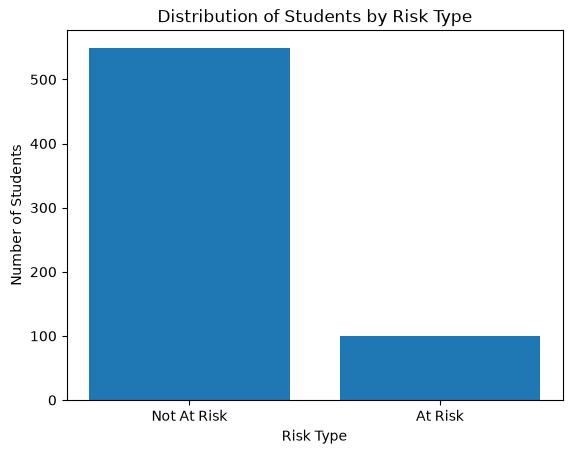

In [12]:
#
riskType = ["Not At Risk", "At Risk"]
studentVariation = [549, 100]

#create barchart
plt.bar(riskType, studentVariation)

#labels and title
plt.xlabel("Risk Type")
plt.ylabel("Number of Students")
plt.title("Distribution of Students by Risk Type")

plt.savefig("../outputs/figures/1-risk_type_distrubution")

plt.show()


# Figure 2- G1 scores


Do students who are eventually at risk have lower G1 grades already (G1 is the first term grades)

In [13]:
#calculate mean G1 for each risk category
g1Avg = dfCsv.groupby("at_risk")["G1"].mean()
g1Avg

at_risk
0    12.058288
1     7.780000
Name: G1, dtype: float64

The At risk average is less than the not risk students. This means the At Risk group scored about 4.28 marks lower in their first-period grade.

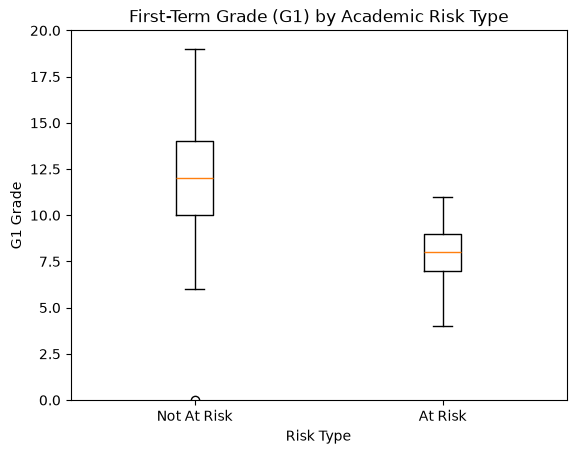

In [14]:
#split G1 data into 2 - risk, no risk - calculate median for each group
dfCsv.groupby("at_risk")["G1"].median()

#grades where student at risk vs not at risk
noRiskG1= dfCsv[dfCsv["at_risk"] ==0]["G1"]
riskG1= dfCsv[dfCsv["at_risk"] ==1]["G1"]


plt.boxplot(
    [noRiskG1, riskG1],
    #2 boxplots, one for each group
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Type")
plt.ylabel("G1 Grade")
plt.title("First-Term Grade (G1) by Academic Risk Type")

plt.ylim(0, 20)


plt.savefig("../outputs/figures/2-risk_Type_g1_boxplot.png")

plt.show()


In [15]:
dfCsv.groupby("at_risk")["G1"].median()

at_risk
0    12.0
1     8.0
Name: G1, dtype: float64

# Figure 3- G2 Scores

Are second-period grades different between students who eventually become At Risk and those who do not?

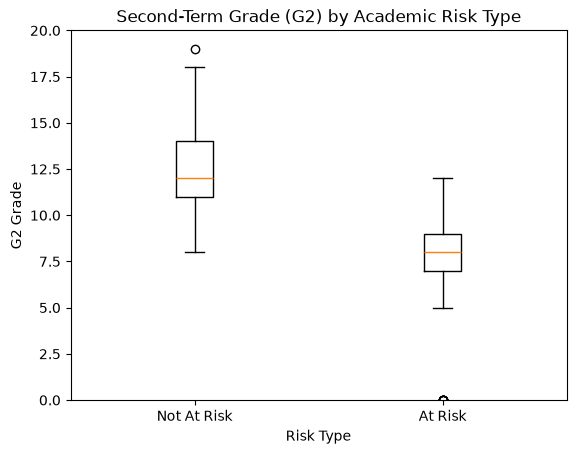

In [16]:
#split G2 data into 2 - risk, no risk - calculate median for each group
dfCsv.groupby("at_risk")["G2"].median()

#grades where student at risk vs not at risk
noRiskG2= dfCsv[dfCsv["at_risk"] ==0]["G2"]
riskG2= dfCsv[dfCsv["at_risk"] ==1]["G2"]


plt.boxplot(
    [noRiskG2, riskG2],
    #2 boxplots, one for each group
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Type")
plt.ylabel("G2 Grade")
plt.title("Second-Term Grade (G2) by Academic Risk Type")

plt.ylim(0, 20)


plt.savefig("../outputs/figures/3-risk_Type_g2_boxplot.png")

plt.show()


In [17]:
dfCsv.groupby("at_risk")["G2"].median()

at_risk
0    12.0
1     8.0
Name: G2, dtype: float64

In [18]:
dfCsv.groupby("at_risk")["G2"].mean()

at_risk
0    12.306011
1     7.530000
Name: G2, dtype: float64

This information shows second-period grades are much lower among students who later fall into the At Risk group.

Students who eventually fall into the At Risk group already have substantially lower G2 performance. This supports the idea that G2 will probably be a strong predictor in Experiment 2.

# Figure 4- Failiures

We would like to compare the percentage of students in each group that had a failiure

In [19]:
#previous failure indicator, if failed before- 1 if not 0
dfCsv["prev_failure"]= (dfCsv["failures"]>0).astype(int)

#calculate percentage of failires for each risk category
percFailiure= dfCsv.groupby("at_risk")["prev_failure"].mean()*100
percFailiure

at_risk
0     9.289617
1    49.000000
Name: prev_failure, dtype: float64

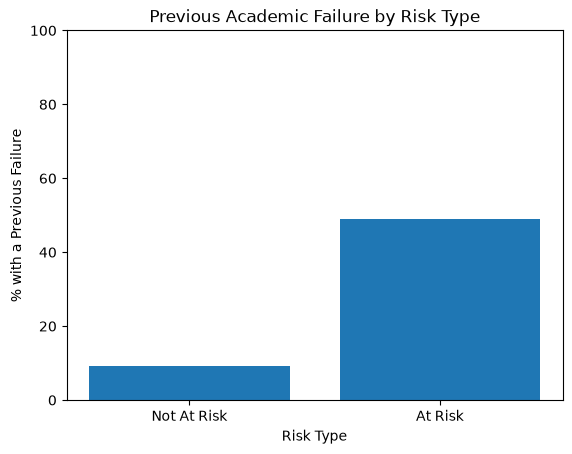

In [20]:
riskType=["Not At Risk", "At Risk"]

plt.bar(riskType,percFailiure)

plt.xlabel("Risk Type")
plt.ylabel("% with a Previous Failure")
plt.title("Previous Academic Failure by Risk Type")

plt.ylim(0, 100)

plt.savefig("../outputs/figures/4-risk_type_previous_failiures.png")
plt.show()

This tells us that previous failiure is far more common in the at risk gategory, around 5 times as common. This makes failiures look potentially useful for our early warning experiment

# Figure 5- Absences

In [21]:
#Mean
dfCsv.groupby("at_risk")["absences"].mean()

at_risk
0    3.486339
1    4.610000
Name: absences, dtype: float64

In [22]:
#Median
dfCsv.groupby("at_risk")["absences"].median()

at_risk
0    2.0
1    2.5
Name: absences, dtype: float64

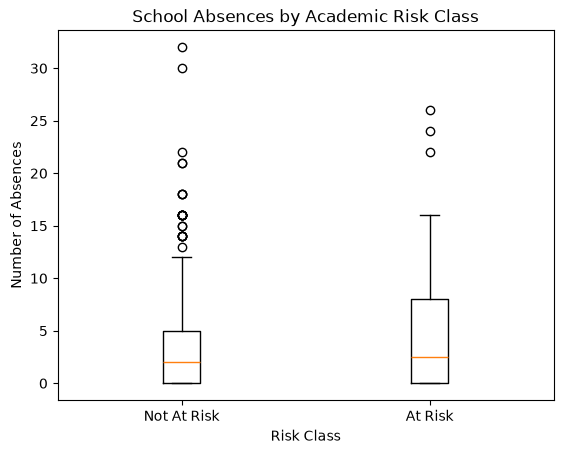

In [23]:
#BOXPLOT 
absencesNoRisk= dfCsv[dfCsv["at_risk"] ==0]["absences"]

absencesRisk= dfCsv[dfCsv["at_risk"] ==1]["absences"]

plt.boxplot(
    [absencesNoRisk, absencesRisk],
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Class")
plt.ylabel("Number of Absences")
plt.title("School Absences by Academic Risk Class")

plt.savefig("../outputs/figures/5-absences_by_risk_boxplot.png")
plt.show()

At-risk students have slightly more absences on average

# Figure 6 - Performance change

How does a student's performance change between G1 and G2?

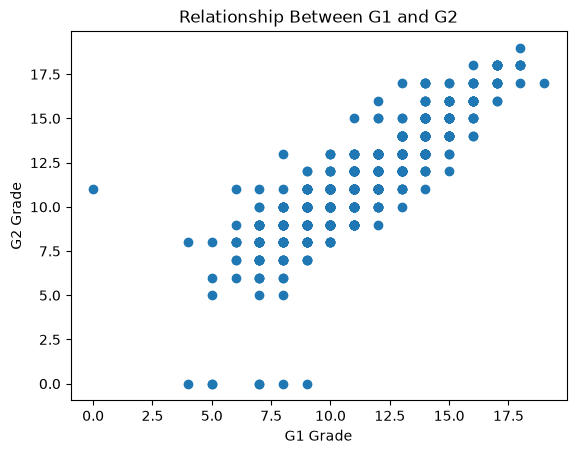

In [24]:
#Scatter Graph
#G1 x pos, G2 y pos
plt.scatter(dfCsv["G1"], dfCsv["G2"])

plt.xlabel("G1 Grade")
plt.ylabel("G2 Grade")
plt.title("Relationship Between G1 and G2")

plt.savefig( "../outputs/figures/6-g1_g2_scatterplot.png",)

plt.show()

In [25]:
#calculate correlation between G1 and G2
g1g2Correlation= dfCsv["G1"].corr(dfCsv["G2"])
g1g2Correlation
round(g1g2Correlation, 3)

np.float64(0.865)

A correlation of 0.865 show that students that score high in G1 generally  score highly in G2 and students with lower G1 generally have lower G2.

# Figure 7- What percentage of each risk group actually declined from G1 to G2?

In [26]:
#new column for grade difference between G1 and G2
dfCsv["grade_change"]= dfCsv["G2"]-dfCsv["G1"]
dfCsv[["G1","G2","grade_change"]].head()

,G1,G2,grade_change
0,0,11,11
1,9,11,2
2,12,13,1
3,14,14,0
4,11,13,2


In [27]:
#mean,median grade change for each risk type
dfCsv.groupby("at_risk")["grade_change"].agg(["mean","median"])

,mean,median
at_risk,,
0,0.247723,0.0
1,-0.250000,0.0


In [28]:
#grade_change< 0 = 1 =declined
#grade_change>=0 = 0 =no decline

dfCsv["declined"] = (dfCsv["grade_change"] <0).astype(int)

#percentage who declined for each risk group
declinePerc= dfCsv.groupby("at_risk")["declined"].mean()*100
declinePerc.round(2)

at_risk
0    27.69
1    35.00
Name: declined, dtype: float64

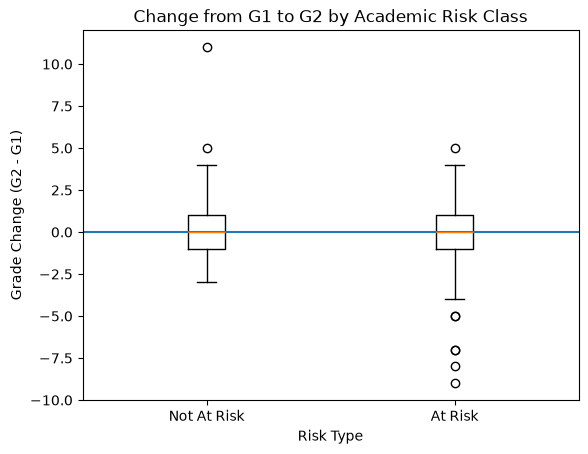

In [29]:
not_at_risk_change = dfCsv[dfCsv["at_risk"] == 0]["grade_change"]

at_risk_change = dfCsv[dfCsv["at_risk"] == 1]["grade_change"]

plt.boxplot(
    [not_at_risk_change, at_risk_change],
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Type")
plt.ylabel("Grade Change (G2 - G1)")
plt.title("Change from G1 to G2 by Academic Risk Class")

#horizontal line at y=0- indicate no change
plt.axhline(0)
plt.savefig("../outputs/figures/7-grade_change_by_risk_boxplot.png")

plt.show()

one Not At Risk student improved massively, about +11
several At Risk students declined substantially, around −5 to −9

This tells us Grade change may contain some useful information, but it doesn't separate  risk groups nearly as strongly as G1, G2 or previous failures.

# Figure 8 - Final EDA summary 

In [30]:
#EDA summary table

eda_summary= pd.DataFrame({
    "Feature": [
        "G1 median",
        "G2 median",
        "Previous failure (%)",
        "Mean absences",
        "Grade decline (%)"
    ],

    "Not At Risk": [
        dfCsv[dfCsv["at_risk"] ==0]["G1"].median(),
        dfCsv[dfCsv["at_risk"] ==0]["G2"].median(),
        dfCsv[dfCsv["at_risk"] ==0]["prev_failure"].mean() * 100,
        dfCsv[dfCsv["at_risk"] ==0]["absences"].mean(),
        dfCsv[dfCsv["at_risk"] ==0]["declined"].mean() * 100
    ],

    "At Risk": [
        dfCsv[dfCsv["at_risk"] ==1]["G1"].median(),
        dfCsv[dfCsv["at_risk"] ==1]["G2"].median(),
        dfCsv[dfCsv["at_risk"] ==1]["prev_failure"].mean()*100,
        dfCsv[dfCsv["at_risk"] ==1]["absences"].mean(),
        dfCsv[dfCsv["at_risk"] ==1]["declined"].mean()*100
    ],

    "Initial observation": [
        "Strong difference",
        "Strong difference",
        "Strong difference",
        "Smaller difference",
        "Smaller difference"
    ]
})

eda_summary.round(2)
plt.savefig("../outputs/figures/8-EDA_summary.png",)

<Figure size 640x480 with 0 Axes>

grade_average = overall level of academic performance
grade_change = whether performance improved or declined

In [31]:
#create average assessment grade colomn (g1+g2)/2
dfCsv["grade_average"]=(dfCsv["G1"] +dfCsv["G2"])/2
dfCsv[["G1", "G2", "grade_average", "grade_change"]].head()

,G1,G2,grade_average,grade_change
0,0,11,5.5,11
1,9,11,10.0,2
2,12,13,12.5,1
3,14,14,14.0,0
4,11,13,12.0,2


## Experiment 1
Can we identify AtRisk students using only previous failures and attendance?

In [32]:
experiment1 =dfCsv[["failures","absences", "at_risk"]].copy()
experiment1.head()

,failures,absences,at_risk
0,0,4,0
1,0,2,0
2,0,6,0
3,0,0,0
4,0,0,0


## Experiment 2A
Can we identify AtRisk students better if we know actual G1 and G2 assessment grades? (if yes, shows earlier academic performance information is useful for predicting)

In [33]:
experiment2a =dfCsv[["failures","absences", "G1","G2", "at_risk"]].copy()
experiment2a.head()

,failures,absences,G1,G2,at_risk
0,0,4,0,11,0
1,0,2,9,11,0
2,0,6,12,13,0
3,0,0,14,14,0
4,0,0,11,13,0


## Experiment 2B
Is it better to represent assessment history using overall average and change in performance, or giving the model G1 and G2 directly?

In [34]:
experiment2b = dfCsv[["prev_failure","absences",
                       "grade_average","grade_change","at_risk"]
                    ].copy()

In [35]:
#debug check (all colomns still there?)
print("Experiment 1 shape:", experiment1.shape)
print("Experiment 2A shape:", experiment2a.shape)
print("Experiment 2B shape:", experiment2b.shape)


Experiment 1 shape: (649, 3)
Experiment 2A shape: (649, 5)
Experiment 2B shape: (649, 5)


## ML Link
Train/test split- model learns from one group and proves whether it correctly predicts risk on different group from dataset which it has not seen before.


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
#x1-innput info model will use to predict if student is at risk or not
X1 =experiment1[["failures","absences"]]
#y1- target variable, if student is at risk or not
y1 =experiment1["at_risk"]

#train/test split
X1_train,X1_test,y1_train,y1_test =train_test_split(
    #failures, absences of students that model will learn from
    X1,
    #real atrisk answers for those same students
    y1,
    test_size=0.20,
    #keep random split same every time run - reproducibility
    random_state=42,
    #roughly same proportion of risk/no risk students in train and test sets
    stratify=y1
)

#check shapes
print("Experiment 1 X train:", X1_train.shape)
print("Experiment 1 X test:", X1_test.shape)
print("Experiment 1 y train:", y1_train.shape)
print("Experiment 1 y test:", y1_test.shape)

#check class balance
print("Experiment 1 Training At Risk %:", round(y1_train.mean()*100,2))
print("Experiment 1 Testing At Risk %:", round(y1_test.mean()*100,2))

Experiment 1 X train: (519, 2)
Experiment 1 X test: (130, 2)
Experiment 1 y train: (519,)
Experiment 1 y test: (130,)
Experiment 1 Training At Risk %: 15.41
Experiment 1 Testing At Risk %: 15.38


In [38]:
#x2a-innput info model will use to predict if student is at risk or not
X2a =experiment2a[["failures","absences","G1","G2"]]
#y2a- target variable, if student is at risk or not
y2a =experiment2a["at_risk"]

#train/test split
X2a_train,X2a_test,y2a_train,y2a_test =train_test_split(
    #failures, absences, G1, G2 of students that model will learn from
    X2a,
    #real atRisk answers for those same students
    y2a,
    test_size=0.20,
    #keep random split same every time run - reproducibility
    random_state=42,
    #roughly same proportion of risk/no risk students in train and test sets
    stratify=y2a
)

#check shapes
print("Experiment 2A X train:", X2a_train.shape)
print("Experiment 2A X test:", X2a_test.shape)
print("Experiment 2A y train:", y2a_train.shape)
print("Experiment 2A y test:", y2a_test.shape)

#check class balance
print("Experiment 2A Training At Risk %:", round(y2a_train.mean()*100,2))
print("Experiment 2A Testing At Risk %:", round(y2a_test.mean()*100,2))

Experiment 2A X train: (519, 4)
Experiment 2A X test: (130, 4)
Experiment 2A y train: (519,)
Experiment 2A y test: (130,)
Experiment 2A Training At Risk %: 15.41
Experiment 2A Testing At Risk %: 15.38


In [39]:
#x2b-innput info model will use to predict if student is at risk or not
X2b =experiment2b[["prev_failure","absences","grade_average","grade_change"]]
#y2b- target variable, if student is at risk or not
y2b =experiment2b["at_risk"]

#train/test split
X2b_train,X2b_test,y2b_train,y2b_test =train_test_split(
    #prev_failure, absences, grade_average, grade_change of students that model will learn from
    X2b,
    #real atrisk answers for those same students
    y2b,
    test_size=0.20,
    #keep random split same every time run - reproducibility
    random_state=42,
    #roughly same proportion of risk/no risk students in train and test sets
    stratify=y2b
)

#check shapes
print("Experiment 2B X train:", X2b_train.shape)
print("Experiment 2B X test:", X2b_test.shape)
print("Experiment 2B y train:", y2b_train.shape)
print("Experiment 2B y test:", y2b_test.shape)

#check class balance
print("Experiment 2B Training At Risk %:", round(y2b_train.mean()*100,2))
print("Experiment 2B Testing At Risk %:", round(y2b_test.mean()*100,2))

Experiment 2B X train: (519, 4)
Experiment 2B X test: (130, 4)
Experiment 2B y train: (519,)
Experiment 2B y test: (130,)
Experiment 2B Training At Risk %: 15.41
Experiment 2B Testing At Risk %: 15.38
